# Lesson Coverage

## Data Preparation

- [ ] Duplicates handled
- [ ] Missing Data checked / handled if necessary
- [ ] Outliers inspected
- [ ] Encoding
- [ ] Scaling

## K-Nearest Neighbors

- [ ] KNN Regression
- [ ] KNN Classification
- [ ] n_neighbors
- [ ] weights
- [ ] p = 1 / Manhattan
- [ ] p = 2 / Euclidean

## Baselines

- [ ] DummyRegressor
- [ ] DummyClassifier

## Regression Metrics

- [ ] Residuals
- [ ] MSE
- [ ] RMSE
- [ ] MAE
- [ ] Max Error
- [ ] R?
- [ ] cross_validate with multiple metrics

## Classification Metrics

- [ ] Confusion Matrix
- [ ] TP
- [ ] TN
- [ ] FP
- [ ] FN
- [ ] Accuracy
- [ ] Precision
- [ ] Recall
- [ ] F1

## Threshold Evaluation

- [ ] LabelEncoder
- [ ] predict_proba
- [ ] cross_val_predict
- [ ] precision_recall_curve
- [ ] Precision?Recall plot
- [ ] Business Recall target
- [ ] Custom Threshold
- [ ] Precision / Recall comparison after threshold change

## ROC

- [ ] ROC Curve
- [ ] True Positive Rate
- [ ] False Positive Rate
- [ ] ROC-AUC

## Final Analysis

- [ ] Error Analysis
- [ ] Cohort Analysis
- [ ] Final metric interpretation

# 1. Project Goal

This project studies how different machine-learning evaluation metrics tell different stories about model performance using the **Medical Insurance Charges** dataset.

The project will explore two distinct machine-learning tasks:

### Task A ? Regression
Predict individual medical insurance `charges` based on patient attributes (age, sex, BMI, children, smoking status, and region).

### Task B ? Classification
Later in the project, we will create a classification target `price_range` with two categories:
- `cheap`
- `expensive`

We will evaluate classification models against various probability thresholds, trade-offs between precision and recall, and ROC-AUC.

> **Scope Notice for Step 1**: In this initial step, we focus exclusively on raw data auditing, quality checks, and outlier inspection. We do **not** create the `price_range` target yet, do **not** apply encodings or scalings, do **not** split into train/test, and do **not** train any models.

# 2. Load Data

We load the raw dataset from `data/insurance.csv` using `pandas` and inspect its basic dimensions and structure.

In [1]:
import pandas as pd

data = pd.read_csv("data/insurance.csv")

In [2]:
data.shape

(1338, 7)

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

The dataset loaded contains 1,338 rows and 7 columns, matching the expected schema:
- `age`: integer / numeric
- `sex`: string categorical (`female`, `male`)
- `bmi`: float continuous
- `children`: integer count
- `smoker`: string categorical (`yes`, `no`)
- `region`: string categorical (`northeast`, `southeast`, `southwest`, `northwest`)
- `charges`: float continuous (regression target)

# 3. Understand the Data

We now examine the data types, non-null counts, and summary statistics across all columns.

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Next, we inspect the frequency distributions of each categorical variable using `value_counts()`.

In [7]:
data["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [8]:
data["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [9]:
data["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

**Categorical Insights:**
- `sex`: Very evenly split between male (676) and female (662).
- `smoker`: Approximately 20.5% smokers (274) and 79.5% non-smokers (1,064). This imbalance will play a critical role in predicting charges.
- `region`: Evenly distributed across all 4 US regions (southeast has slightly more records at 364, while the others have 324?325).

# 4. Duplicates

We check for duplicate rows in the dataset using `duplicated()` and calculate the total count.

In [10]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [11]:
duplicate_count = data.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 1


In [12]:
if duplicate_count > 0:
    display(data[data.duplicated(keep=False)])
else:
    print("No duplicate rows found.")

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Duplicate observations can distort model evaluation if the same observation appears in both training and test data.

Inspection reveals 1 duplicate pair (row 195 and row 581: a 19-year-old male, non-smoker, BMI 30.59, 0 children, northwest, charge 1639.5631).

In Step 1, we do **not** remove duplicates yet, preserving the raw dataset exactly as loaded for audit purposes.

# 5. Missing Data

We check for missing or null values in each feature and across the entire dataset.

In [13]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
total_missing = data.isnull().sum().sum()
print(f"Total missing values: {total_missing}")

Total missing values: 0


The dataset contains no missing values, so imputation is not required for this project.

# 6. Numerical / Categorical Features

We partition features by their data type into numerical and categorical subsets.

In [15]:
numerical_features = ["age", "bmi", "children", "charges"]
categorical_features = ["sex", "smoker", "region"]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'bmi', 'children', 'charges']
Categorical features: ['sex', 'smoker', 'region']


In [16]:
data[numerical_features].dtypes

age           int64
bmi         float64
children      int64
charges     float64
dtype: object

In [17]:
data[categorical_features].dtypes

sex       str
smoker    str
region    str
dtype: object

**Distance-Based Algorithm Considerations:**

K-Nearest Neighbors (KNN) is a distance-based algorithm (computing Euclidean or Manhattan distances between data points). Consequently:
1. **Categorical features** (`sex`, `smoker`, `region`) cannot be used directly in distance formulas and will later require numerical representation (e.g., One-Hot Encoding).
2. **Numerical features** (`age`, `bmi`, `children`) have vastly different scales (e.g. `age` spans 18?64, `bmi` spans 15.96?53.13, while `charges` spans 1,121?63,770). Without appropriate feature scaling (e.g. `StandardScaler` or `RobustScaler`), features with larger magnitudes would arbitrarily dominate distance calculations.

# 7. Potential Outliers

We inspect the distribution, central tendencies, dispersion, and skewness of all numerical features.

In [18]:
summary_stats = pd.DataFrame({
    "min": data[numerical_features].min(),
    "max": data[numerical_features].max(),
    "mean": data[numerical_features].mean(),
    "median": data[numerical_features].median(),
    "std": data[numerical_features].std(),
    "skewness": data[numerical_features].skew()
})
summary_stats

,min,max,mean,median,std,skewness
age,18.0000,64.00000,39.207025,39.000,14.049960,0.055673
bmi,15.9600,53.13000,30.663397,30.400,6.098187,0.284047
children,0.0000,5.00000,1.094918,1.000,1.205493,0.938380
charges,1121.8739,63770.42801,13270.422265,9382.033,12110.011237,1.515880


We visualize the distributions and potential outliers for `bmi` and `charges` using simple `matplotlib` boxplots.

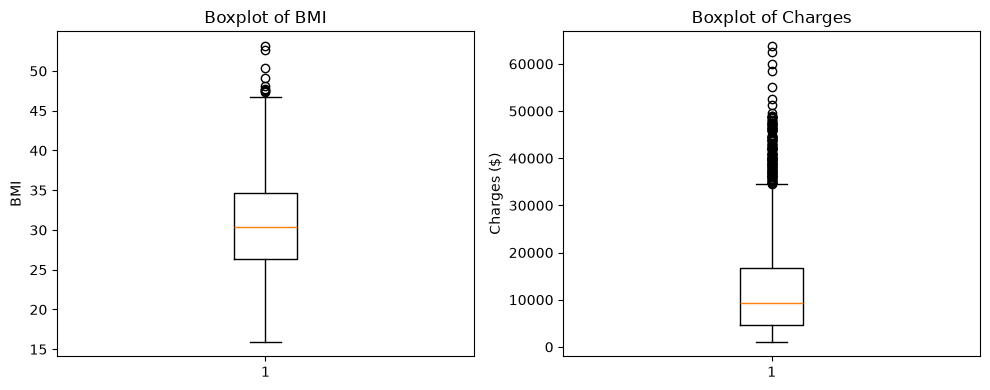

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(data["bmi"].dropna())
plt.title("Boxplot of BMI")
plt.ylabel("BMI")

plt.subplot(1, 2, 2)
plt.boxplot(data["charges"].dropna())
plt.title("Boxplot of Charges")
plt.ylabel("Charges ($)")

plt.tight_layout()
plt.show()

An extreme value is not automatically an error. Outliers should be interpreted in the context of the business problem before deciding whether to remove or transform them.

**Outlier Analysis:**
- **BMI**: Min is 15.96, max is 53.13, mean is 30.66, median is 30.40, with slight skewness (0.28). The boxplot displays a few points above BMI 47. These represent extreme clinical obesity, which is biologically realistic and medically valid.
- **Charges**: Min is $1,121.87, max is $63,770.43, mean is $13,270.42, median is $9,382.03, and skewness is 1.51 (substantially right-skewed). The boxplot displays numerous high values beyond the upper whisker. In health insurance, high medical charges typically reflect severe illnesses, intensive treatments, surgeries, or high-risk smoking patients. These are authentic real-world business events rather than data errors and must not be blindly removed.

# 8. First Data-Preparation Decisions

Based on the raw data audit performed in Step 1, here is the synthesis of requirements for Step 2:

1. **Duplicates**:
   - The dataset contains 1 duplicate row. In Step 2, we will evaluate removing this duplicate prior to train/test splitting to prevent potential train-test leakage.

2. **Missing Values**:
   - Total missing values is 0 across all features. No imputation (e.g. `SimpleImputer`) will be required.

3. **Categorical Features**:
   - Features `sex`, `smoker`, and `region` are strings. In Step 2, they will be transformed using One-Hot Encoding (`OneHotEncoder`) or binary mapping before feeding into distance-based models.

4. **Numerical Features**:
   - Features `age`, `bmi`, and `children` have different scales. Because K-Nearest Neighbors relies on distance calculations, scaling (such as `StandardScaler` or `RobustScaler`) will be necessary to ensure balanced feature influence.

5. **Outliers**:
   - Extreme values in `bmi` and `charges` reflect genuine healthcare scenarios and patient populations. They will not be dropped blindly; robust scaling or appropriate evaluation metrics (such as MAE alongside RMSE) will be used to assess model robustness against extreme values.

> Note: No modifications, splits, encodings, scalings, or models have been executed in Step 1.